# Búsqueda de mejor modelo con cortes preestablecidos

## Modelos iniciales

In [ ]:
df_clinico = pd.read_csv("df_clinico.csv")
df_sin_analisis = pd.read_csv("df_sin_analisis.csv")

In [140]:
import numpy as np
import pandas as pd

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Helper para matriz de confusión
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# =========================
# Datos
# =========================
y = df_clinico["GDM1"].astype(int)
X = df_clinico.drop(columns=["GDM1"]).copy()

# Split estratificado para evaluación final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Shape X:", X.shape)
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Columnas:", X.columns.tolist())
print("Distribución target:\n", y.value_counts())

# Configuración de validación
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=123)

# Almacenar resultados CV
resultados_modelos = []

# Almacenar resultados TEST
resultados_test = []

def mostrar_matriz_confusion_test(nombre, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Matriz de confusión - {nombre} (test)")
    plt.tight_layout()
    plt.show()

Shape X: (1878, 7)
Shape X_train: (1502, 7)
Shape X_test: (376, 7)
Columnas: ['diabetes franca 1T', 'etnia', 'factores riesgo', 'edad>=35', 'obesidad', 'gluc 1t>100', 'hba1c 1t>5,7']
Distribución target:
 GDM1
0    1775
1     103
Name: count, dtype: int64


In [141]:
# Nueva celda (previa a buscar modelos):
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Configuración CV y scoring
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

# Listas para guardar resultados (solo CV, SIN test)
resultados_modelos = []

LR - ROC_AUC (CV): mean=0.7160 | std=0.0658 | 95% CI=[0.7031, 0.7289]
LR - PR_AUC (CV): mean=0.2712 | std=0.0967 | 95% CI=[0.2522, 0.2901]
LR - F1 (CV): mean=0.1946 | std=0.0395 | 95% CI=[0.1869, 0.2024]


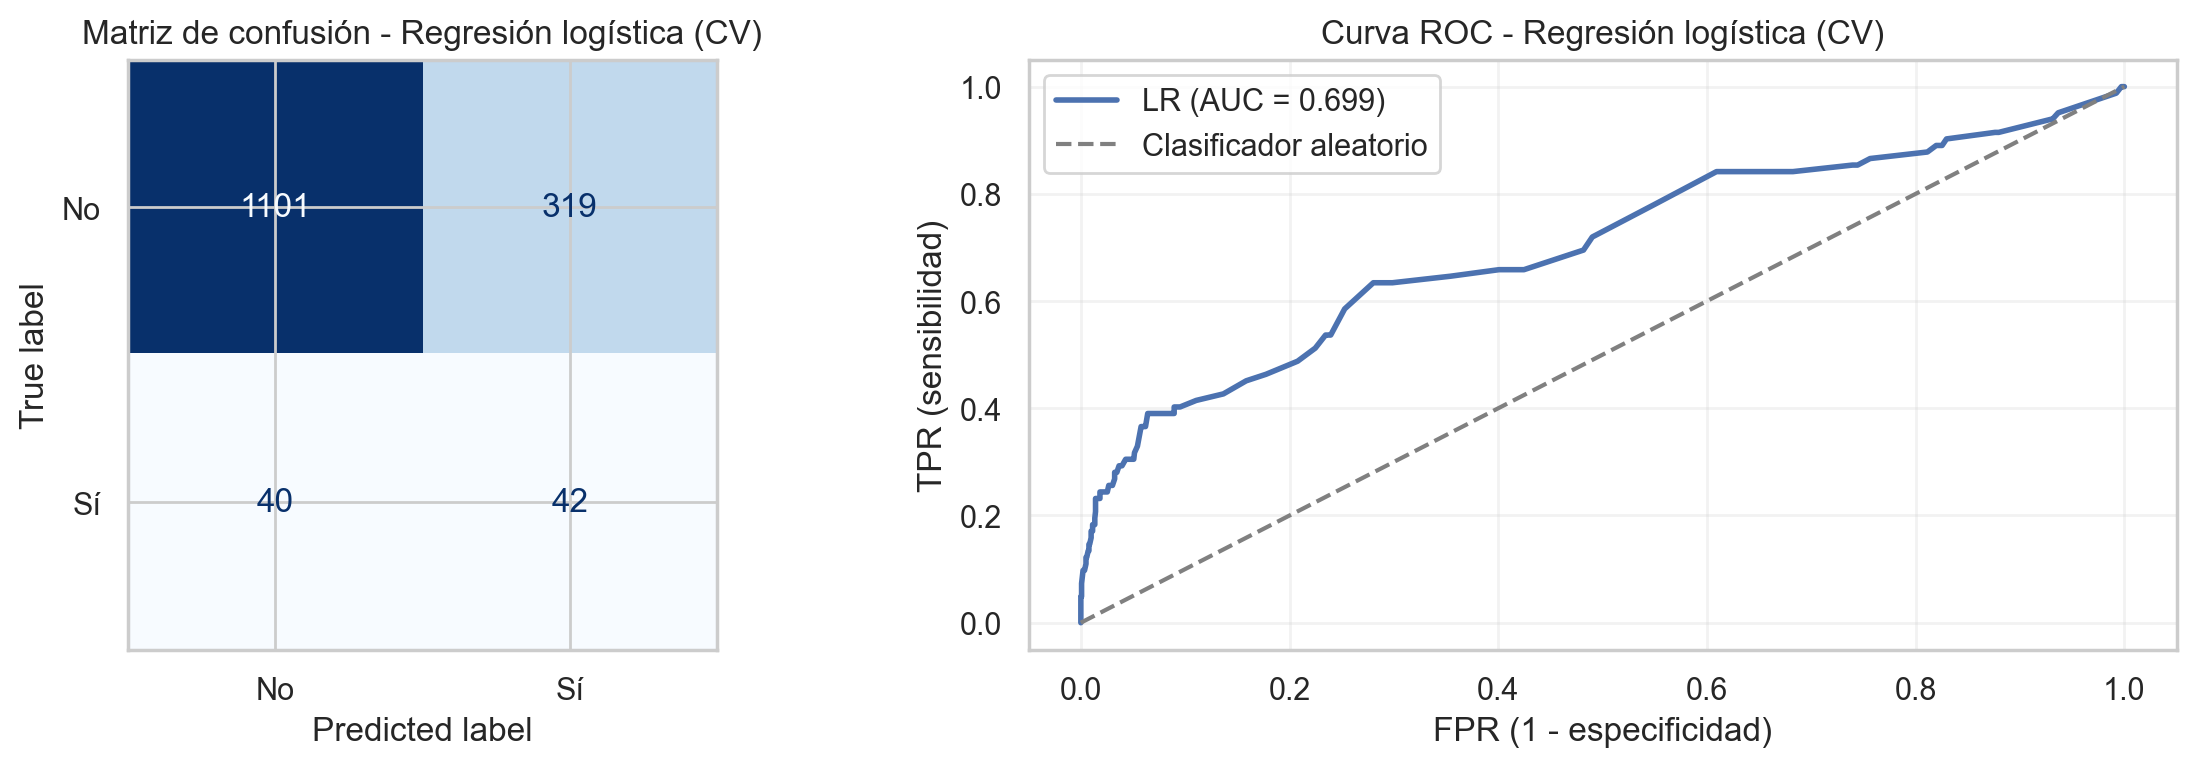

In [142]:
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

def build_pipeline_lr(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
    ])
    return model

pipe_lr = build_pipeline_lr(X_train)

# === Validación cruzada: métricas (con cv original) ===
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_lr = cross_validate(pipe_lr, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_lr[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "Regresión logística",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"LR - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

# === Predicciones en CV para plots (usar StratifiedKFold) ===
cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_lr, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_lr, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

# === Plots: Matriz de confusión + Curva ROC en una figura ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión
cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - Regresión logística (CV)")

# Curva ROC
fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"LR (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - Regresión logística (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

RF - ROC_AUC (CV): mean=0.7006 | std=0.0661 | 95% CI=[0.6877, 0.7136]
RF - PR_AUC (CV): mean=0.2078 | std=0.0708 | 95% CI=[0.1939, 0.2216]
RF - F1 (CV): mean=0.1897 | std=0.0424 | 95% CI=[0.1814, 0.1980]


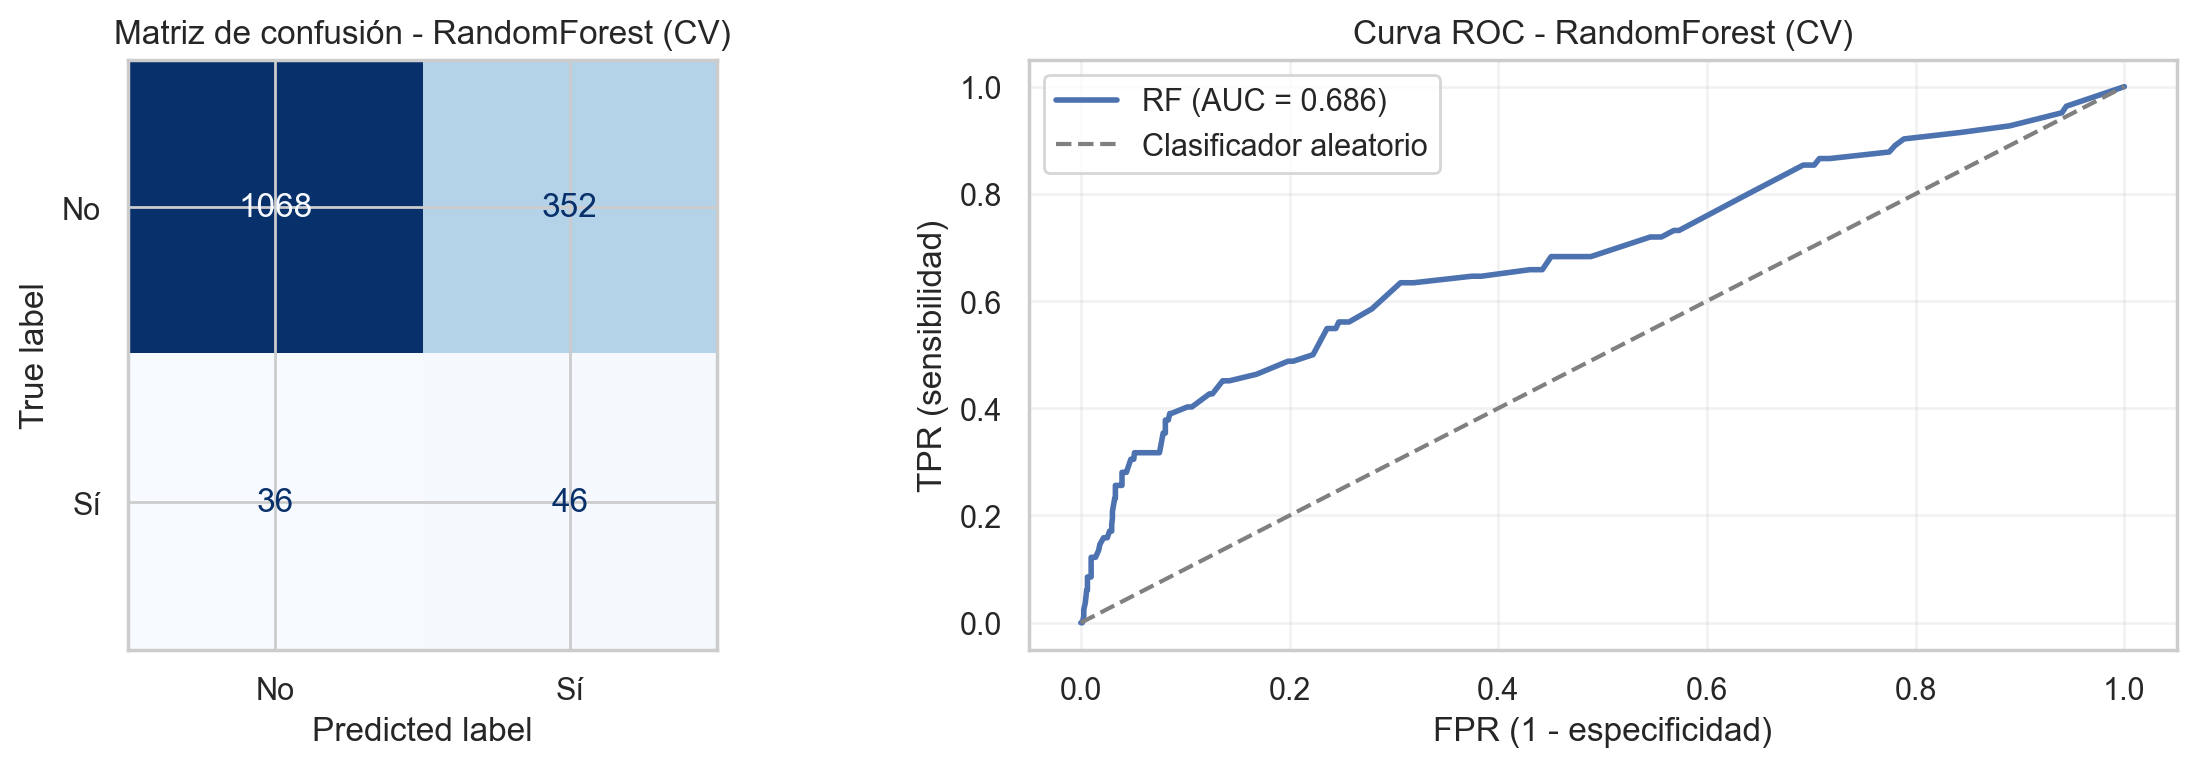

In [143]:
from sklearn.ensemble import RandomForestClassifier

def build_pipeline_rf(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", RandomForestClassifier(
            n_estimators=500, 
            max_depth=10, 
            min_samples_leaf=20, 
            class_weight="balanced",
            random_state=42, 
            n_jobs=-1
        ))
    ])
    return model

pipe_rf = build_pipeline_rf(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_rf = cross_validate(pipe_rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_rf[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "RandomForest",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"RF - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_rf, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_rf, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - RandomForest (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"RF (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - RandomForest (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

HGB - ROC_AUC (CV): mean=0.6885 | std=0.0672 | 95% CI=[0.6753, 0.7017]
HGB - PR_AUC (CV): mean=0.2530 | std=0.0885 | 95% CI=[0.2356, 0.2703]
HGB - F1 (CV): mean=0.1720 | std=0.1019 | 95% CI=[0.1520, 0.1919]


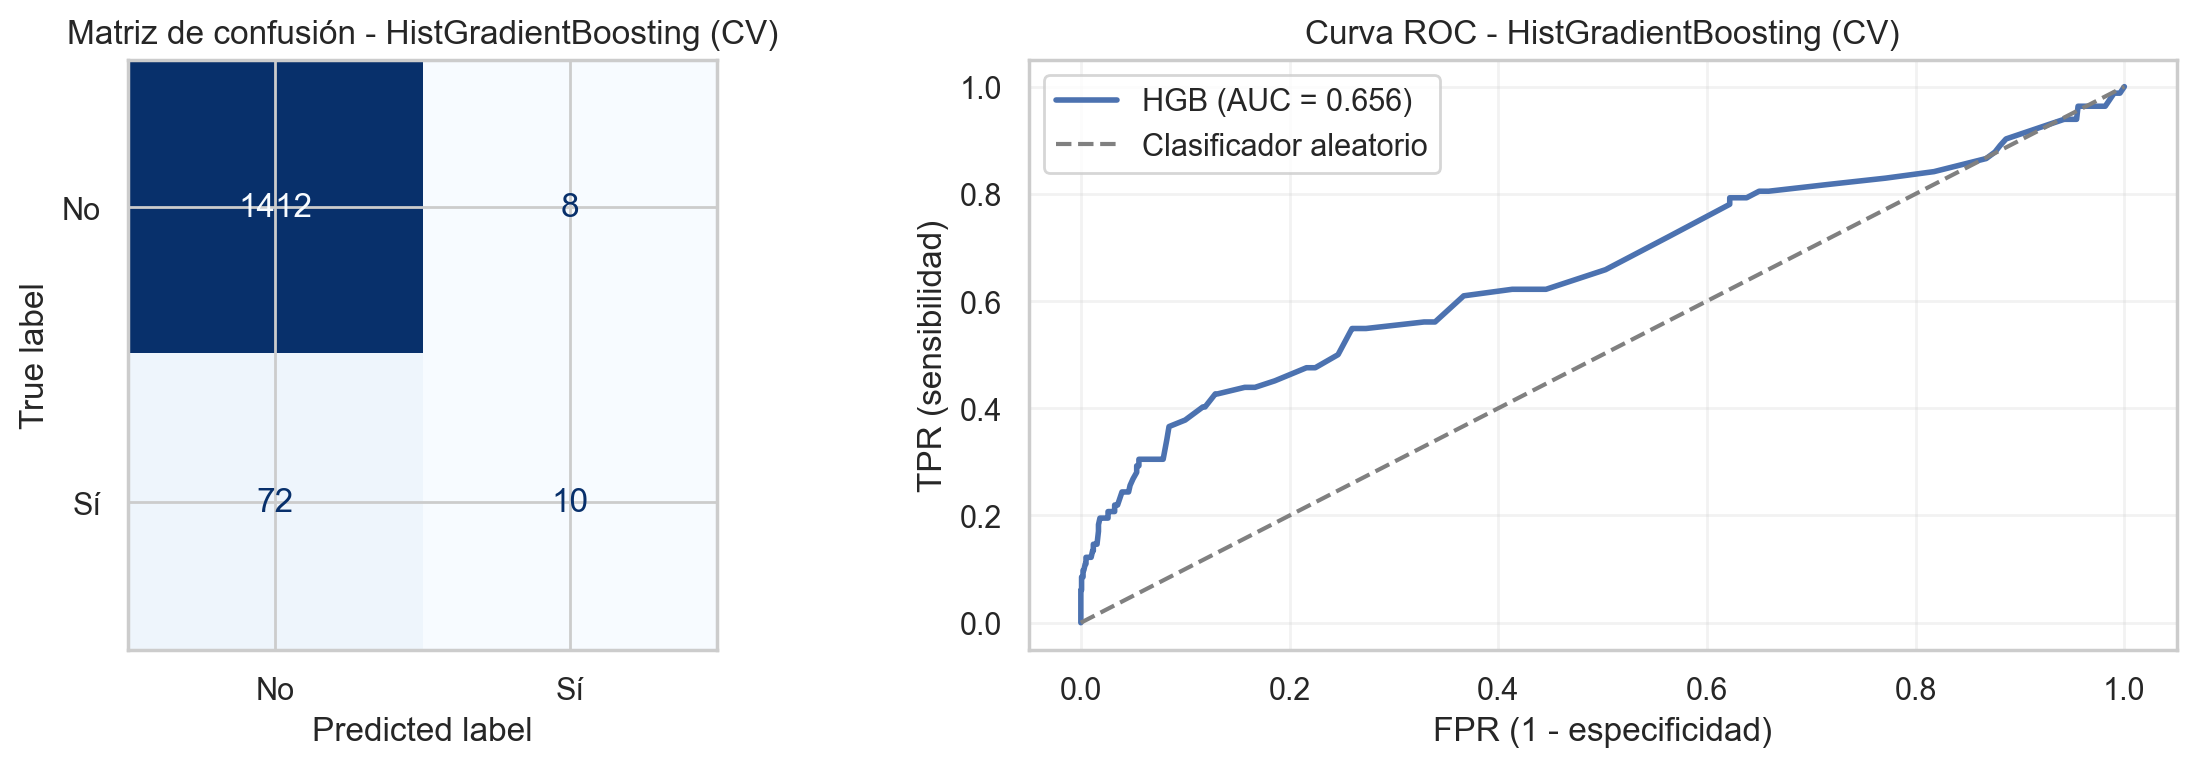

In [144]:
import warnings
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

def build_pipeline_hgb(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=300, max_depth=6, min_samples_leaf=20, random_state=42
        ))
    ])
    return model

pipe_hgb = build_pipeline_hgb(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_hgb = cross_validate(pipe_hgb, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_hgb[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "HistGradientBoosting",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"HGB - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_hgb, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_hgb, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - HistGradientBoosting (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"HGB (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - HistGradientBoosting (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

ET - ROC_AUC (CV): mean=0.6527 | std=0.0728 | 95% CI=[0.6384, 0.6669]
ET - PR_AUC (CV): mean=0.2362 | std=0.0895 | 95% CI=[0.2186, 0.2537]
ET - F1 (CV): mean=0.1886 | std=0.0523 | 95% CI=[0.1783, 0.1988]


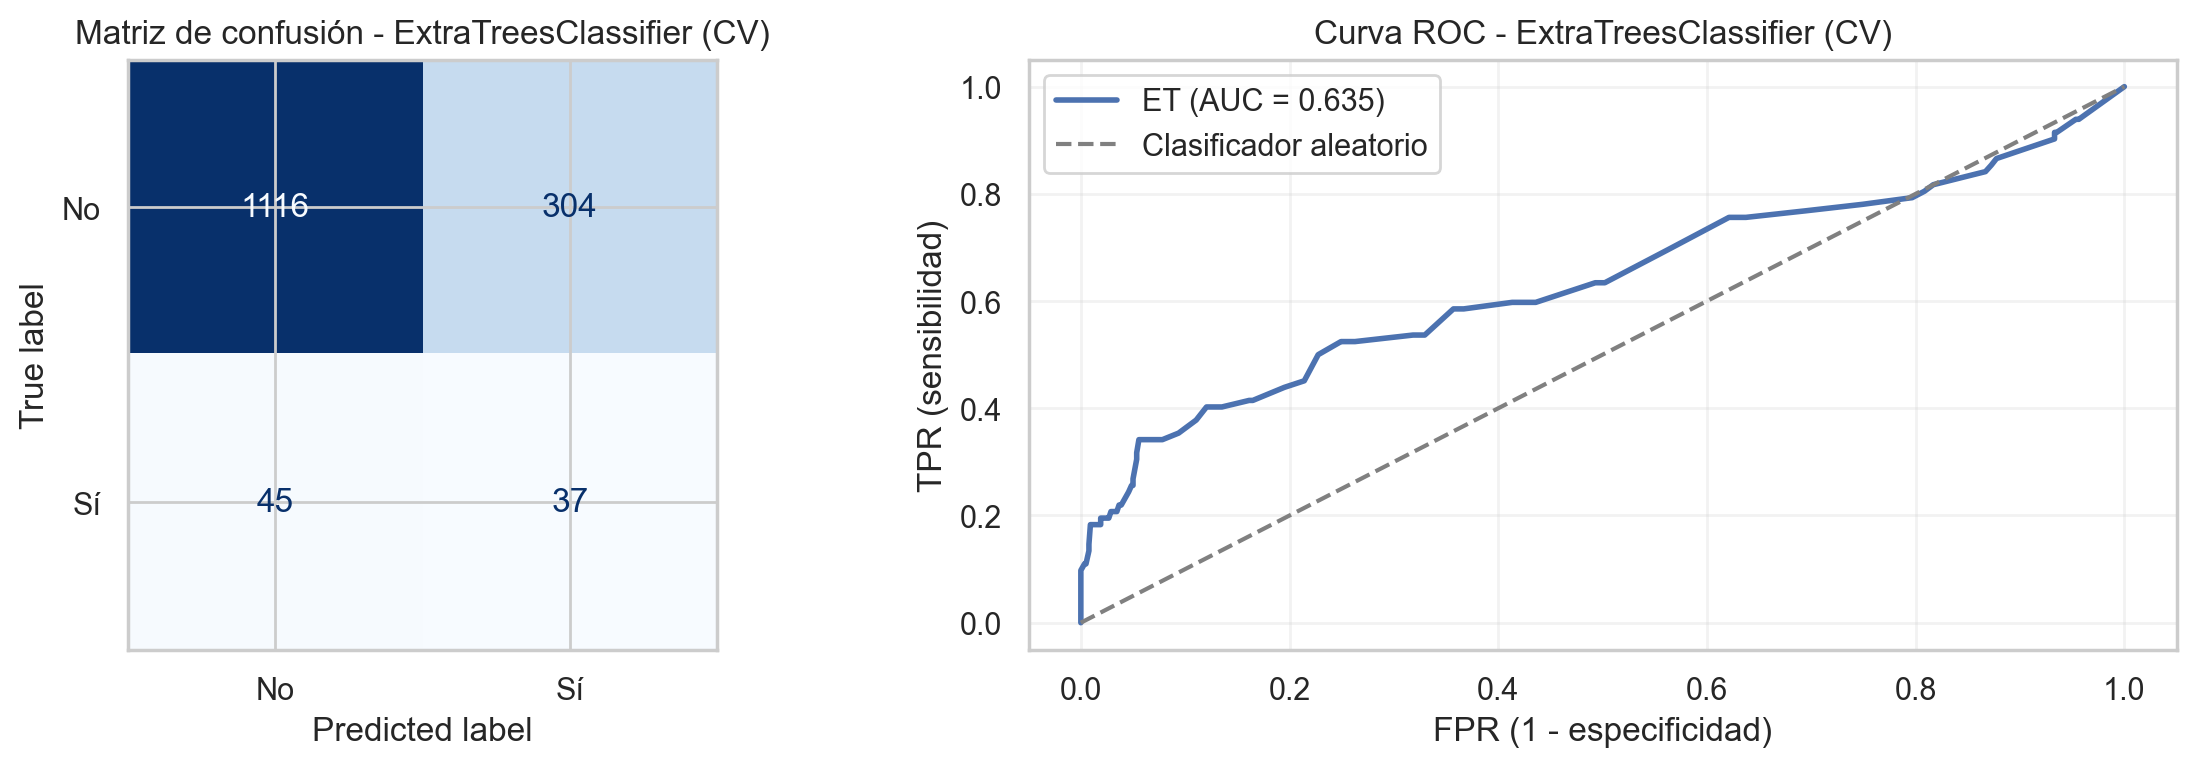

In [145]:
from sklearn.ensemble import ExtraTreesClassifier

def build_pipeline_et(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1))
    ])
    return model

pipe_et = build_pipeline_et(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_et = cross_validate(pipe_et, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_et[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "ExtraTreesClassifier",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"ET - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_et, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_et, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - ExtraTreesClassifier (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"ET (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - ExtraTreesClassifier (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

CB - ROC_AUC (CV): mean=0.6649 | std=0.0690 | 95% CI=[0.6513, 0.6784]
CB - PR_AUC (CV): mean=0.2520 | std=0.0887 | 95% CI=[0.2346, 0.2694]
CB - F1 (CV): mean=0.1768 | std=0.1003 | 95% CI=[0.1571, 0.1965]


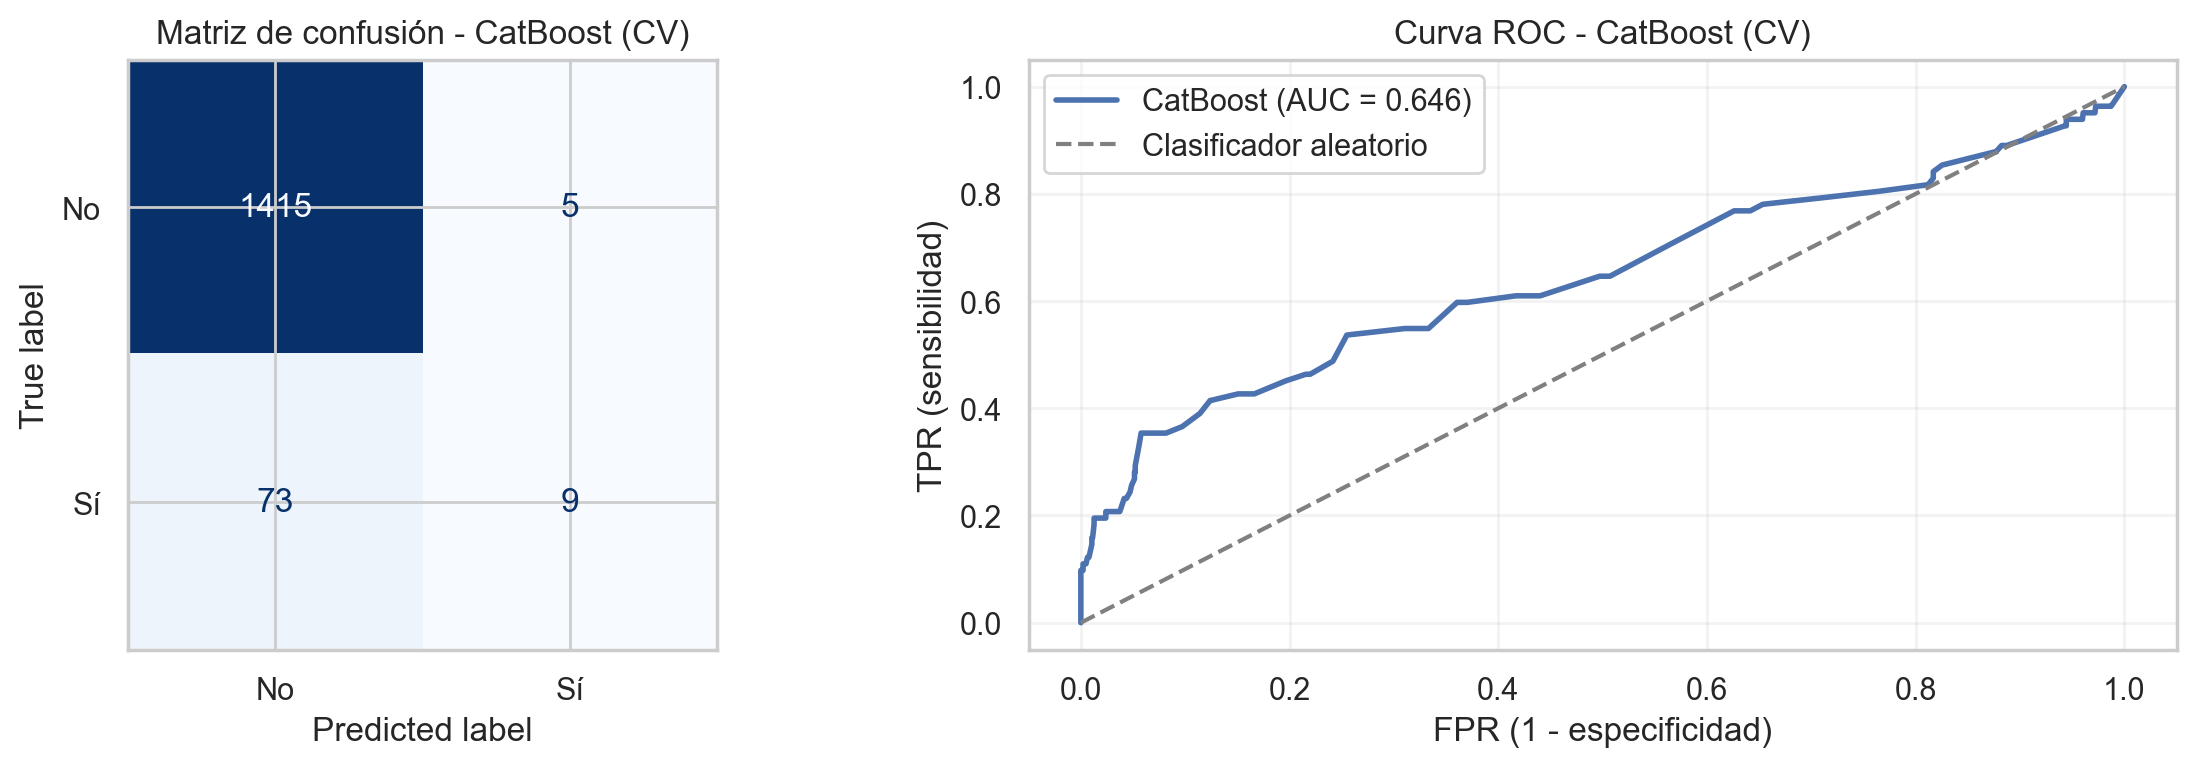

In [146]:
from catboost import CatBoostClassifier

def build_pipeline_cb(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", CatBoostClassifier(
            iterations=300, 
            learning_rate=0.05, 
            depth=6, 
            min_data_in_leaf=20, 
            random_state=42,
            verbose=0
        ))
    ])
    return model

pipe_cb = build_pipeline_cb(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_cb = cross_validate(pipe_cb, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_cb[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "CatBoost",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"CB - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_cb, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_cb, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - CatBoost (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"CatBoost (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - CatBoost (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

SVM - ROC_AUC (CV): mean=0.6631 | std=0.0744 | 95% CI=[0.6485, 0.6777]
SVM - PR_AUC (CV): mean=0.1794 | std=0.0739 | 95% CI=[0.1649, 0.1939]
SVM - F1 (CV): mean=0.1978 | std=0.0527 | 95% CI=[0.1875, 0.2082]


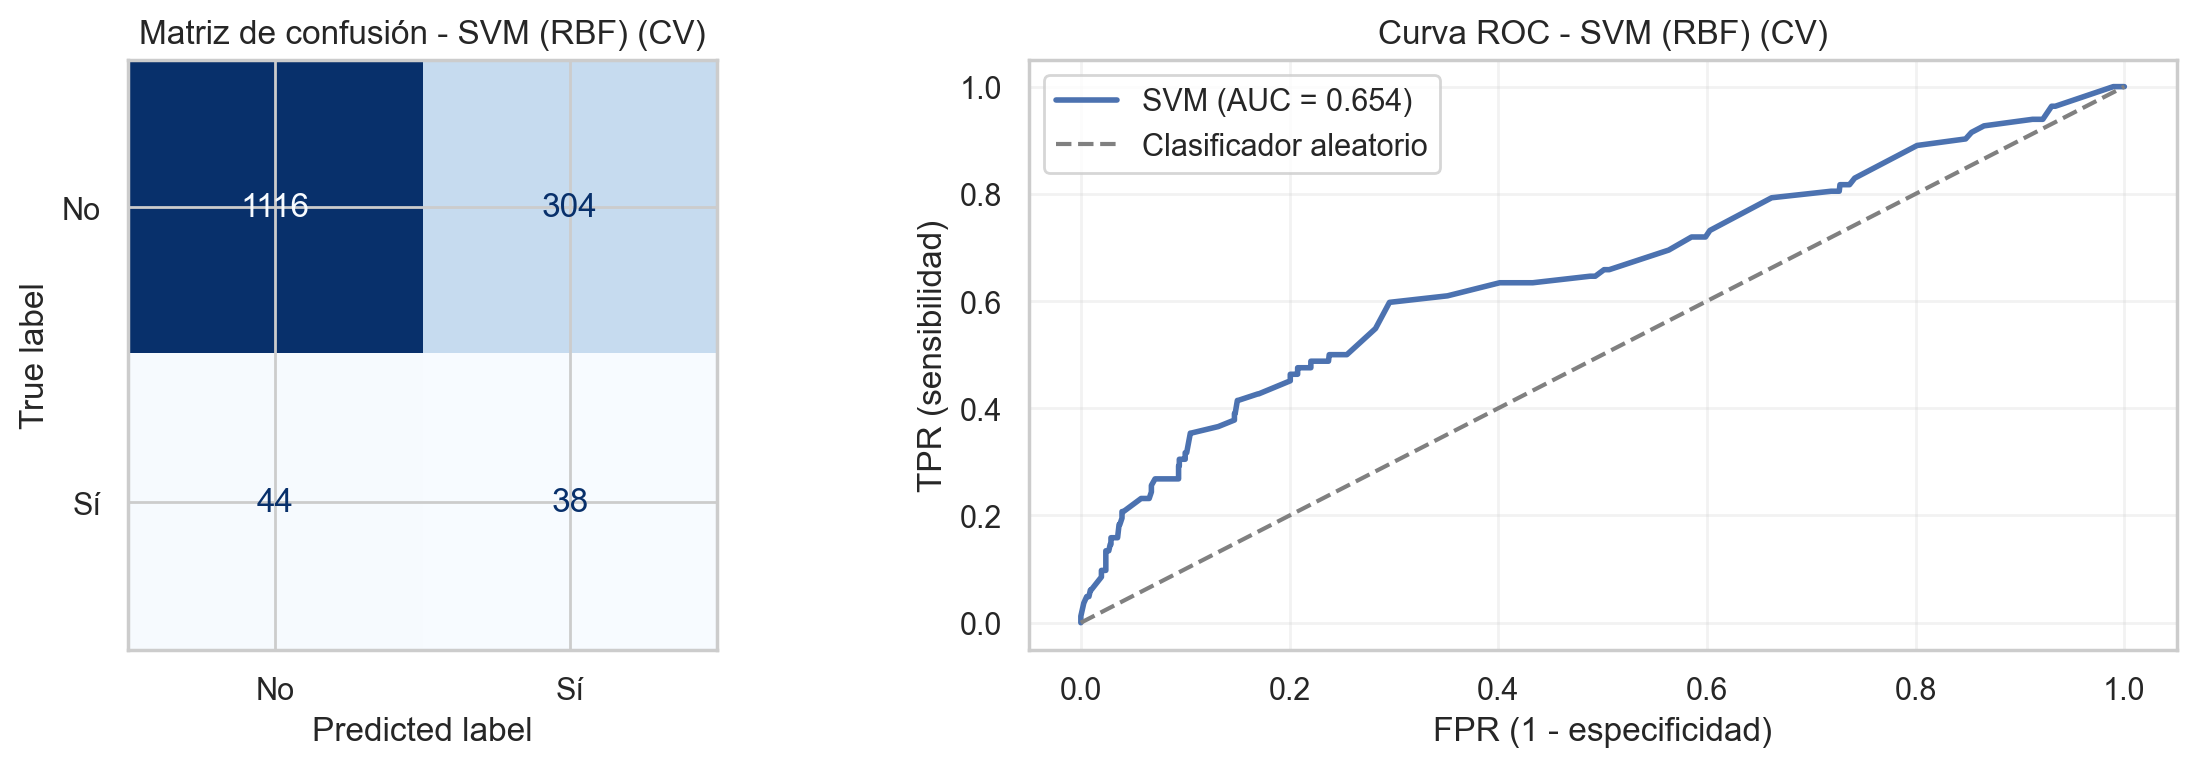

In [147]:
from sklearn.svm import SVC

def build_pipeline_svm(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )

    model = Pipeline([
        ("prep", pre),
        ("clf", SVC(
            kernel="rbf",
            C=0.5,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ])
    return model

pipe_svm = build_pipeline_svm(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_svm = cross_validate(pipe_svm, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_svm[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "SVM (RBF)",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"SVM - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_svm, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_svm, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - SVM (RBF) (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"SVM (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - SVM (RBF) (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

MLP - ROC_AUC (CV): mean=0.6908 | std=0.0677 | 95% CI=[0.6775, 0.7040]
MLP - PR_AUC (CV): mean=0.2552 | std=0.0900 | 95% CI=[0.2375, 0.2728]
MLP - F1 (CV): mean=0.1556 | std=0.1125 | 95% CI=[0.1335, 0.1776]


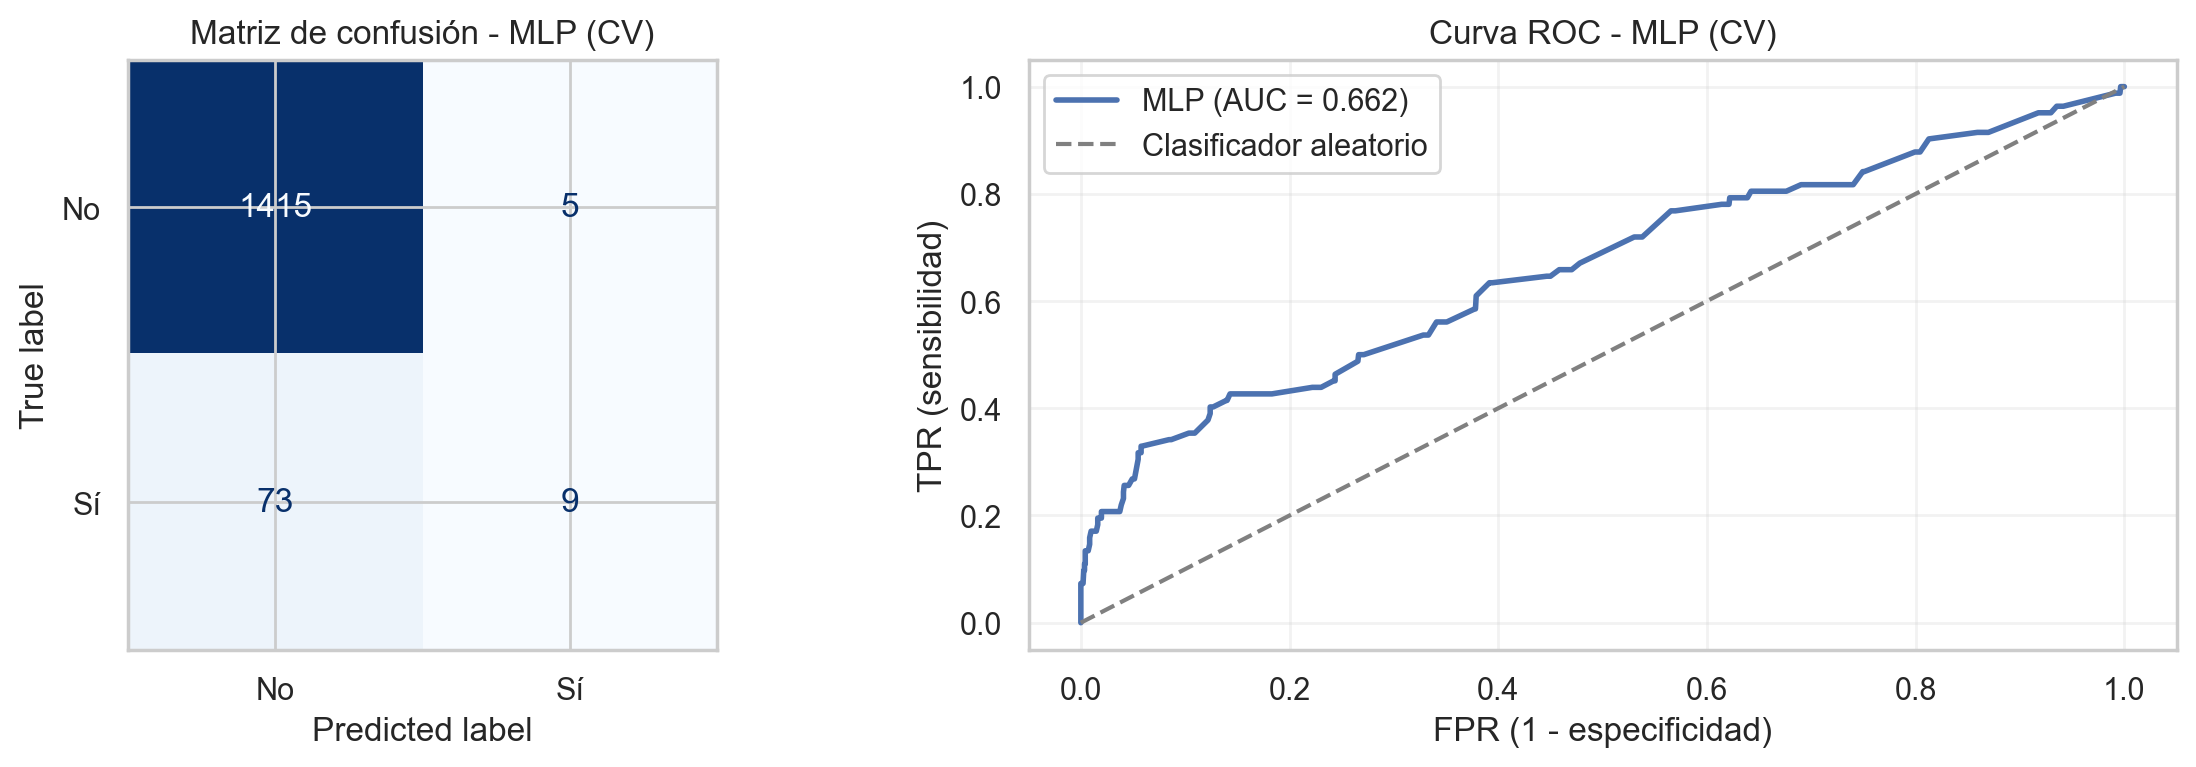

In [148]:
from sklearn.neural_network import MLPClassifier

def build_pipeline_mlp(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))
    ])
    return model

pipe_mlp = build_pipeline_mlp(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_mlp = cross_validate(pipe_mlp, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_mlp[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "MLP",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"MLP - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_mlp, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_mlp, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - MLP (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"MLP (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - MLP (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

GBM - ROC_AUC (CV): mean=0.6900 | std=0.0648 | 95% CI=[0.6773, 0.7027]
GBM - PR_AUC (CV): mean=0.2547 | std=0.0884 | 95% CI=[0.2374, 0.2720]
GBM - F1 (CV): mean=0.1650 | std=0.0997 | 95% CI=[0.1454, 0.1845]


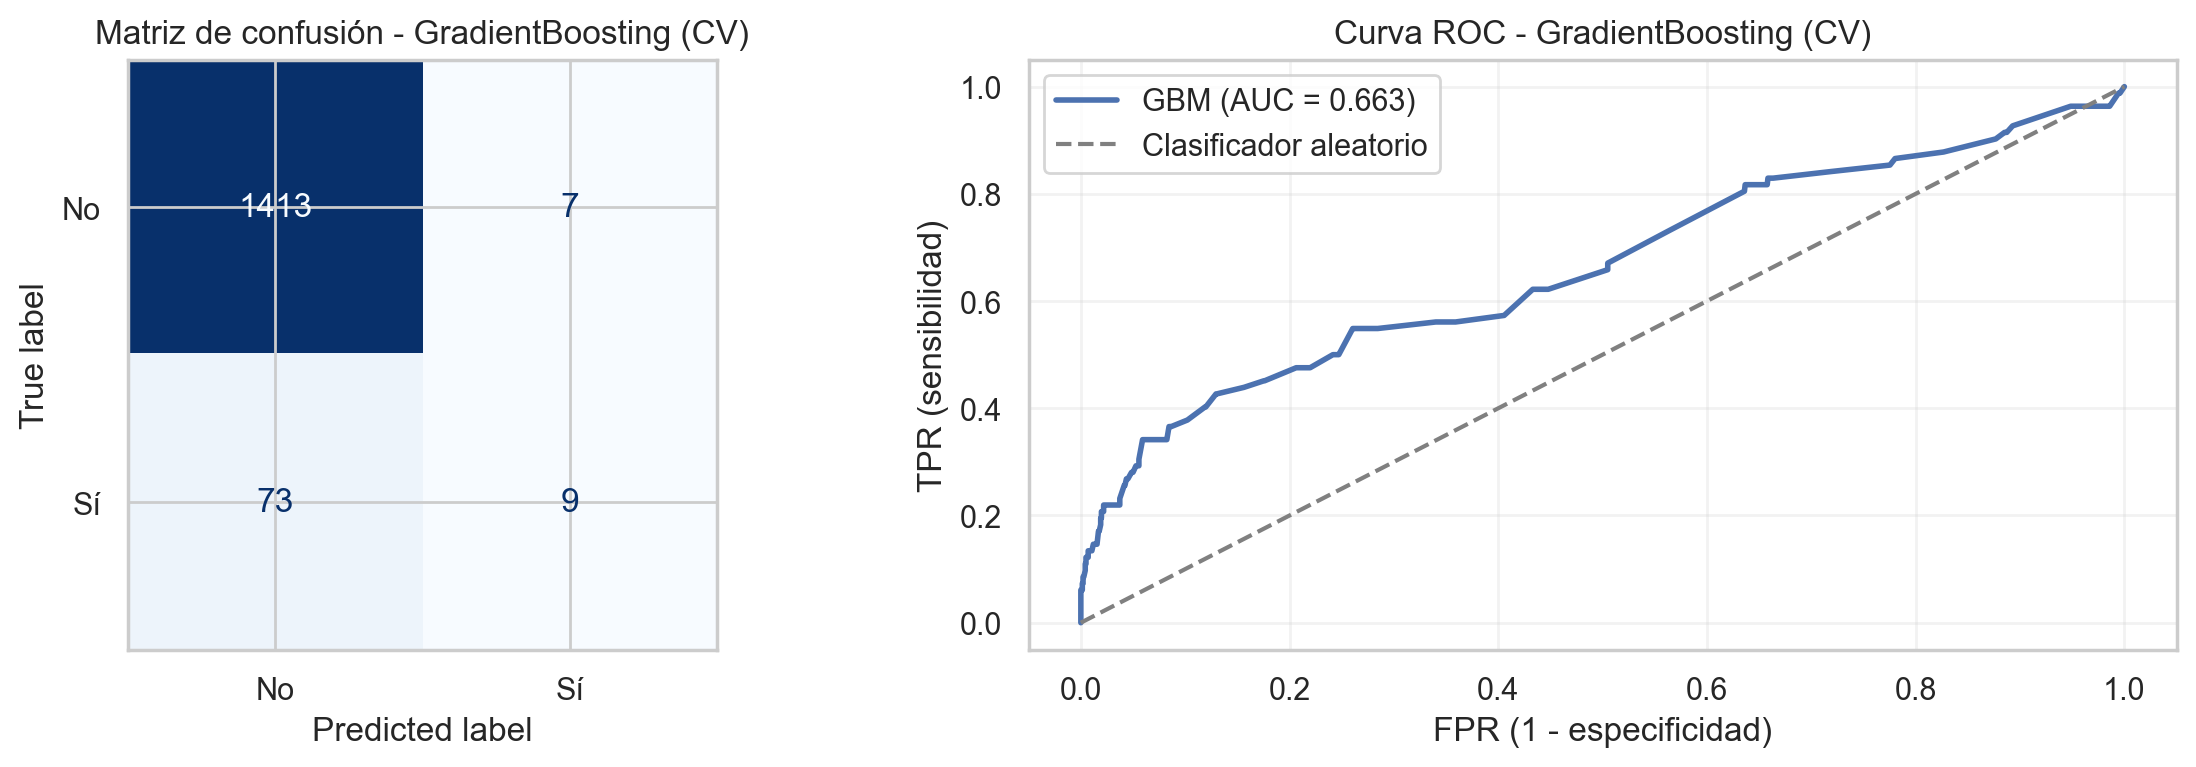

In [149]:
from sklearn.ensemble import GradientBoostingClassifier

def build_pipeline_gbm(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4, min_samples_leaf=20, subsample=0.9, random_state=42
        ))
    ])
    return model

pipe_gbm = build_pipeline_gbm(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_gbm = cross_validate(pipe_gbm, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_gbm[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "GradientBoosting",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"GBM - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_gbm, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_gbm, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - GradientBoosting (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"GBM (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - GradientBoosting (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

XGB - ROC_AUC (CV): mean=0.6920 | std=0.0646 | 95% CI=[0.6793, 0.7046]
XGB - PR_AUC (CV): mean=0.2556 | std=0.0894 | 95% CI=[0.2380, 0.2731]
XGB - F1 (CV): mean=0.1792 | std=0.1018 | 95% CI=[0.1592, 0.1991]


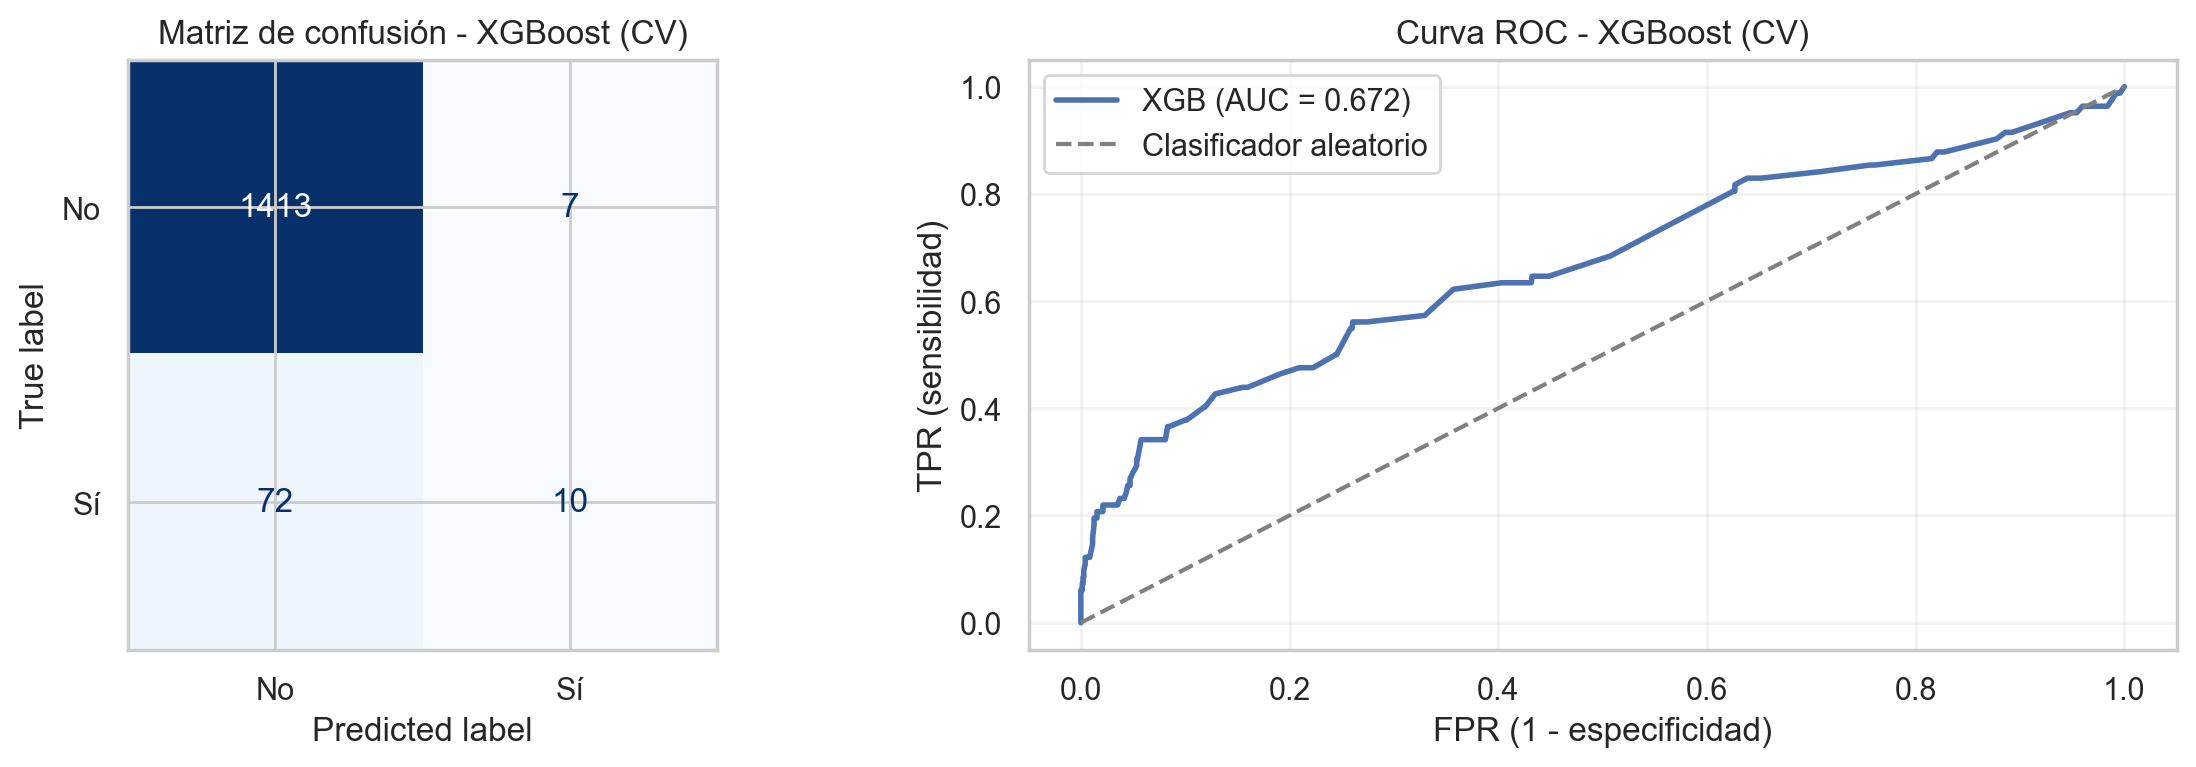

In [150]:
from xgboost import XGBClassifier

def build_pipeline_xgb(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), cat_cols),
        ]
    )
    model = Pipeline([
        ("prep", pre),
        ("clf", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
    return model

pipe_xgb = build_pipeline_xgb(X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_xgb = cross_validate(pipe_xgb, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

for metrica in ["roc_auc", "pr_auc", "f1"]:
    scores = scores_xgb[f"test_{metrica}"]
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    ci95 = 1.96 * std / np.sqrt(len(scores))

    resultados_modelos.append({
        "modelo": "XGBoost",
        "metrica": metrica,
        "mean": mean,
        "std": std,
        "ci95_low": mean - ci95,
        "ci95_high": mean + ci95
    })

    print(f"XGB - {metrica.upper()} (CV): mean={mean:.4f} | std={std:.4f} | 95% CI=[{mean-ci95:.4f}, {mean+ci95:.4f}]")

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_cv = cross_val_predict(pipe_xgb, X_train, y_train, cv=cv_plot)
    y_proba_cv = cross_val_predict(pipe_xgb, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión - XGBoost (CV)")

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
axes[1].plot(fpr, tpr, label=f"XGB (AUC = {roc_auc_cv:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[1].set_xlabel("FPR (1 - especificidad)")
axes[1].set_ylabel("TPR (sensibilidad)")
axes[1].set_title("Curva ROC - XGBoost (CV)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [151]:
import pandas as pd

# Tabla comparativa CV (media)
res_cv = pd.DataFrame(resultados_modelos)

tabla_cv = (
    res_cv.pivot_table(
        index="modelo",
        columns="metrica",
        values="mean",
        aggfunc="first"
    )
    .reindex(columns=["roc_auc", "pr_auc", "f1"])
    .sort_values("roc_auc", ascending=False)
)

print("\n" + "=" * 85)
print("TABLA RESUMEN CV (métricas en validación cruzada)")
print("=" * 85)
display(tabla_cv.round(4))

# Detalle ROC-AUC con IC95
detalle_cv_roc = (
    res_cv[res_cv["metrica"] == "roc_auc"]
    .sort_values("mean", ascending=False)
    [["modelo", "mean", "std", "ci95_low", "ci95_high"]]
    .reset_index(drop=True)
)

print("\n" + "=" * 85)
print("DETALLE CV ROC-AUC (mean ± std, IC95)")
print("=" * 85)
display(detalle_cv_roc.round(4))


TABLA RESUMEN CV (métricas en validación cruzada)


metrica,roc_auc,pr_auc,f1
modelo,,,
Regresión logística,0.7160,0.2712,0.1946
RandomForest,0.7006,0.2078,0.1897
XGBoost,0.6920,0.2556,0.1792
MLP,0.6908,0.2552,0.1556
GradientBoosting,0.6900,0.2547,0.1650
HistGradientBoosting,0.6885,0.2530,0.1720
CatBoost,0.6649,0.2520,0.1768
SVM (RBF),0.6631,0.1794,0.1978
ExtraTreesClassifier,0.6527,0.2362,0.1886



DETALLE CV ROC-AUC (mean ± std, IC95)


,modelo,mean,std,ci95_low,ci95_high
0,Regresión logística,0.7160,0.0658,0.7031,0.7289
1,RandomForest,0.7006,0.0661,0.6877,0.7136
2,XGBoost,0.6920,0.0646,0.6793,0.7046
3,MLP,0.6908,0.0677,0.6775,0.7040
4,GradientBoosting,0.6900,0.0648,0.6773,0.7027
5,HistGradientBoosting,0.6885,0.0672,0.6753,0.7017
6,CatBoost,0.6649,0.0690,0.6513,0.6784
7,SVM (RBF),0.6631,0.0744,0.6485,0.6777
8,ExtraTreesClassifier,0.6527,0.0728,0.6384,0.6669
